# GBDT vs NN

Thin orchestration notebook for the default `NN` vs `GBDT` analysis.

In [20]:
from __future__ import annotations

import sys
from pathlib import Path

notebook_dir = Path.cwd()
project_dir = notebook_dir.parent
repo_root = project_dir.parent

sys.path.insert(0, str(project_dir / "src"))
sys.path.insert(0, str(repo_root / "tabarena" / "tabarena"))

In [21]:
from mfa import load_config, run_analysis

config = load_config(project_dir / "configs" / "config_0.yaml")
result = run_analysis(config)
result.analysis_table.head()

WARNING mfa.groups: Group `tfm` contains config_types absent from data: TABICLV2, TABICL_GPU, TABPFN-V2.6


,dataset,comparison_name,group_a_name,group_b_name,group_a_label,group_b_label,expected_direction,n_splits,n,d,...,best_a_error,best_a_norm_error,best_b_error,best_b_norm_error,delta_raw,delta_raw_std,delta_raw_sem,delta_norm,delta_norm_std,delta_norm_sem


In [22]:
import pandas as pd

# -- Inspect what the result object contains --
print(f"config_hash:        {result.config_hash}")
print(f"comparison_name:    {result.comparison_name}")
print(f"analysis_table:     {result.analysis_table.shape}")
print(f"gap_table:          {result.gap_table.shape}")
print(f"metafeature_table:  {result.metafeature_table.shape}")
print(f"correlation_results: {len(result.correlation_results)} features tested")
print(
    f"correction_result:  {result.correction_result.method if result.correction_result else None}"
)
print(f"multivariate_result: {result.multivariate_result}")

config_hash:        c328ae63c6517838
comparison_name:    nn_vs_tree
analysis_table:     (0, 24)
gap_table:          (816, 17)
metafeature_table:  (816, 9)
correlation_results: 6 features tested
correction_result:  bh
multivariate_result: None


## Correlation summary table

In [23]:
import numpy as np

# Build a comprehensive table from correlation + correction results
corr_df = pd.DataFrame([r.__dict__ for r in result.correlation_results])

if result.correction_result is not None:
    corr_df["p_value_adj"] = result.correction_result.adjusted_p_values
    corr_df["rejected"] = result.correction_result.rejected

# Add a significance star column for quick scanning
p_col = "p_value_adj" if "p_value_adj" in corr_df.columns else "p_value"
corr_df["sig"] = np.where(
    corr_df[p_col] < 0.001,
    "***",
    np.where(corr_df[p_col] < 0.01, "**", np.where(corr_df[p_col] < 0.05, "*", "")),
)

display_cols = [
    "predictor",
    "statistic",
    "ci_lower",
    "ci_upper",
    "p_value",
    *(["p_value_adj", "rejected"] if "p_value_adj" in corr_df.columns else []),
    "sig",
    "n_observations",
    "direction_confirmed",
]

corr_df[display_cols].sort_values("p_value")

,predictor,statistic,ci_lower,ci_upper,p_value,p_value_adj,rejected,sig,n_observations,direction_confirmed
0,n,NaN,None,None,NaN,NaN,False,,0,None
1,d,NaN,None,None,NaN,NaN,False,,0,None
2,log_n,NaN,None,None,NaN,NaN,False,,0,None
3,n_over_d,NaN,None,None,NaN,NaN,False,,0,None
4,cat_fraction,NaN,None,None,NaN,NaN,False,,0,None
5,missing_fraction,NaN,None,None,NaN,NaN,False,,0,None


## Correlation scatter plots

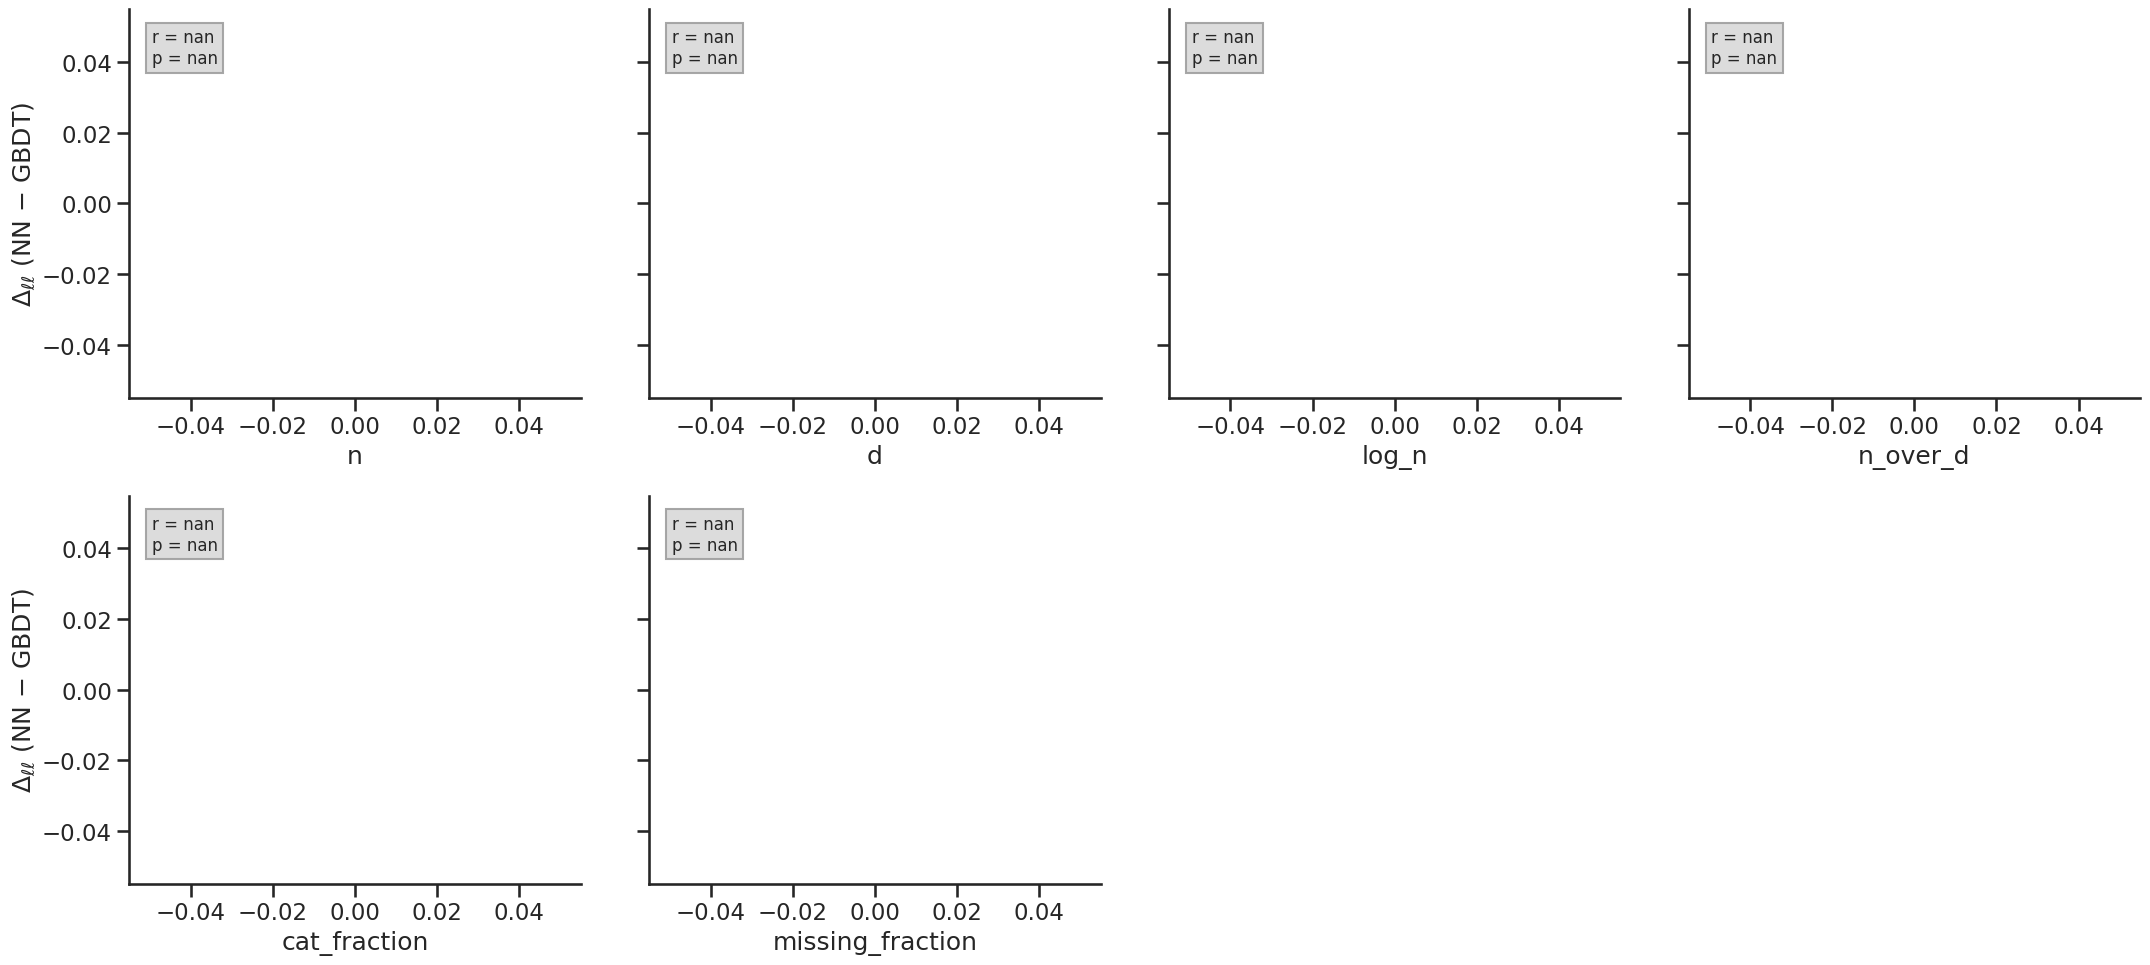

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="talk")

analysis = result.analysis_table.copy()
predictors = corr_df["predictor"].tolist()
n_preds = len(predictors)
ncols = min(4, n_preds)
nrows = int(np.ceil(n_preds / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5.5 * ncols, 5 * nrows), sharey=True, squeeze=False
)

for idx, predictor in enumerate(predictors):
    ax = axes[idx // ncols][idx % ncols]
    plot_df = analysis[[predictor, "delta_norm"]].dropna()

    # Use log scale for features that are strictly positive and span orders of magnitude
    use_log = (plot_df[predictor] > 0).all() and (
        plot_df[predictor].max() / plot_df[predictor].min() > 10
    )

    sns.scatterplot(data=plot_df, x=predictor, y="delta_norm", s=35, alpha=0.85, ax=ax)
    if use_log:
        ax.set_xscale("log")

    ax.set_xlabel(predictor)
    if idx % ncols == 0:
        ax.set_ylabel(r"$\Delta_{\ell\ell}$ (NN − GBDT)")
    else:
        ax.set_ylabel("")

    # Annotate with correlation and adjusted p-value
    row = corr_df.loc[corr_df["predictor"] == predictor].iloc[0]
    p_display = row.get("p_value_adj", row["p_value"])
    ax.text(
        0.05,
        0.95,
        f"r = {row['statistic']:.3f}\np = {p_display:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        bbox={"facecolor": "#d9d9d9", "edgecolor": "#9e9e9e", "alpha": 0.9},
    )

# Hide unused subplots
for idx in range(n_preds, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

sns.despine()
fig.tight_layout()
plt.show()